# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [2]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [3]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
df["pct_change"] = (
    (df["attend_h1_2026"] - df["attend_h1_2025"])
    / df["attend_h1_2025"]
    * 100
)

display(df)

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]

print(
    f"Largest fall: {largest_fall['triage_name']} "
    f"({largest_fall['pct_change']:.2f}%)"
)
print(
    f"Largest rise: {largest_rise['triage_name']} "
    f"({largest_rise['pct_change']:.2f}%)"
)

triage_4_5 = df[df["triage"].isin([4, 5])]
total_2025 = triage_4_5["attend_h1_2025"].sum()
total_2026 = triage_4_5["attend_h1_2026"].sum()
combined_change = (total_2026 - total_2025) / total_2025 * 100

print(
    f"4+5 combined: {total_2025:,} → {total_2026:,} "
    f"({combined_change:.2f}%)"
)




,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


Largest fall: Non-urgent (-20.00%)
Largest rise: Critical (5.00%)
4+5 combined: 507,480 → 456,732 (-10.00%)


In [5]:
# Task 1 note
task1_note = """
REPLACE: 1–2 sentences.
- Triage 1–2 mainly rose or fell? rose
- Triage 4–5 mainly rose or fell? fell
- Short link to the A&E claim (lower-urgency down; critical/emergency protected).
"""
print(task1_note)




REPLACE: 1–2 sentences.
- Triage 1–2 mainly rose or fell? rose
- Triage 4–5 mainly rose or fell? fell
- Short link to the A&E claim (lower-urgency down; critical/emergency protected).



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


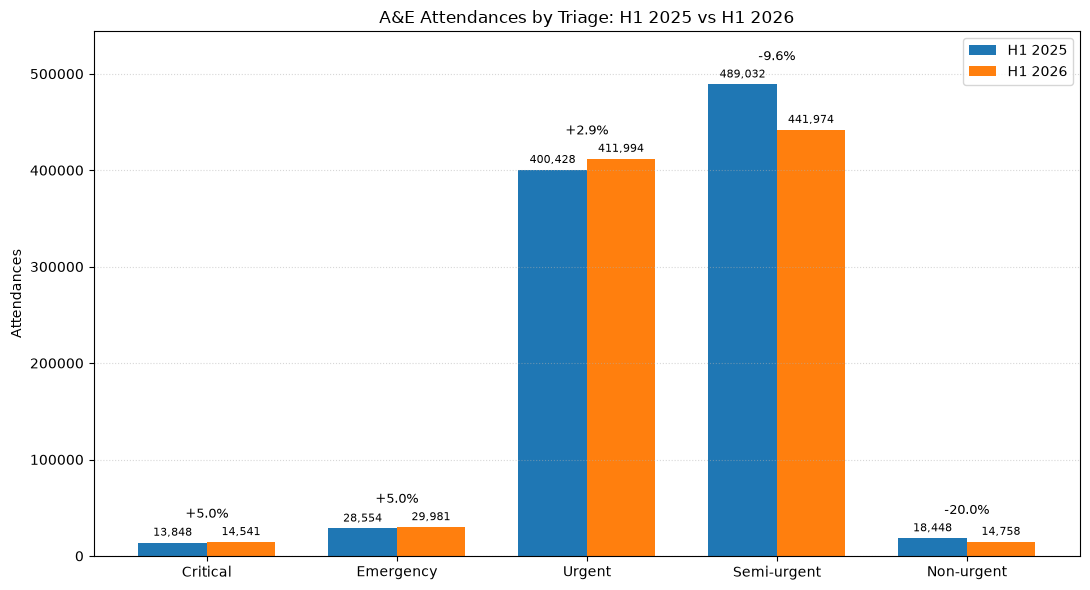

In [10]:
# Task 2 — write your own IPO prompt in the comments, then use Inline Chat
#
# Input: 使用 Task 1 的 df，包含五个分诊组、2025和2026上半年人数及百分比变化。
#
# Process: 为每个分诊组绘制两根并排柱子，分别表示两个年份；
#          在柱子上标注人数，并在每组上方标注百分比变化。
# Output: 显示一张分组柱状图，比较五个分诊组在两个年份的人数。
#
# YOUR CODE BELOW

x = list(range(len(df)))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

bars_2025 = ax.bar(
    [i - width / 2 for i in x],
    df["attend_h1_2025"],
    width,
    label="H1 2025",
)
bars_2026 = ax.bar(
    [i + width / 2 for i in x],
    df["attend_h1_2026"],
    width,
    label="H1 2026",
)

ax.bar_label(
    bars_2025,
    labels=[f"{value:,}" for value in df["attend_h1_2025"]],
    padding=3,
    fontsize=8,
)
ax.bar_label(
    bars_2026,
    labels=[f"{value:,}" for value in df["attend_h1_2026"]],
    padding=3,
    fontsize=8,
)

for i, row in enumerate(df.itertuples()):
    highest = max(row.attend_h1_2025, row.attend_h1_2026)
    ax.text(
        i,
        highest + 22_000,
        f"{row.pct_change:+.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(df["triage_name"])
ax.set_ylabel("Attendances")
ax.set_title("A&E Attendances by Triage: H1 2025 vs H1 2026")
ax.set_ylim(0, df[["attend_h1_2025", "attend_h1_2026"]].to_numpy().max() + 55_000)
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [12]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
Triage 5 non-urgent attendances fell from 18,448 in H1 2025 to 14,758 in H1 2026, a decrease of about 20%. Triage 4 attendances also fell by about 9.6%.
3a GAP (1 point):The table compares only two half-year periods and has no comparison group. Other factors may explain the changes, so it cannot show that the fee reform caused them.
"""

task3b = """
3b:The table and chart partly support the claim: lower-urgency attendances fell, while Triage 1 and 2 attendances each rose by about 5%. The reported Triage III figures also show improvement: the percentage seen within 30 minutes rose from 81.4% to 88.5%, and mean wait time fell from 23 to 20 minutes. However, two periods of data are not enough to prove that the fee reform caused these changes or that A&E improved overall.
REPLACE: 2–4 sentences on how well the claim is supported by the published evidence.
"""

print(task3a)
print("---")
print(task3b)




3a SUPPORT (1 point, cite a number):
Triage 5 non-urgent attendances fell from 18,448 in H1 2025 to 14,758 in H1 2026, a decrease of about 20%. Triage 4 attendances also fell by about 9.6%.
3a GAP (1 point):The table compares only two half-year periods and has no comparison group. Other factors may explain the changes, so it cannot show that the fee reform caused them.

---

3b:The table and chart partly support the claim: lower-urgency attendances fell, while Triage 1 and 2 attendances each rose by about 5%. The reported Triage III figures also show improvement: the percentage seen within 30 minutes rose from 81.4% to 88.5%, and mean wait time fell from 23 to 20 minutes. However, two periods of data are not enough to prove that the fee reform caused these changes or that A&E improved overall.
REPLACE: 2–4 sentences on how well the claim is supported by the published evidence.



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
